In [1]:
pip install transformers datasets torch scikit-learn pandas numpy accelerate

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cpu
CUDA available: False


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import files
uploaded = files.upload()  # Upload dataset_merged.csv

Saving dataset_pendidikan.csv to dataset_pendidikan.csv


In [5]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Model configs
MBERT_MODEL = "bert-base-multilingual-cased"
XLMR_MODEL = "xlm-roberta-base"

# Label mapping (original 1-7 -> 0-6)
LABEL_NAMES = {
    0: "senang",
    1: "percaya",
    2: "terkejut",
    3: "netral",
    4: "takut",
    5: "sedih",
    6: "marah"
}
LABEL_MAPPING = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
NUM_LABELS = 7

# Training hyperparameters
MAX_LENGTH = 256
BATCH_SIZE = 16  # Kurangi jika OOM
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

# Data split
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_SEED = 42

# Paths
DATA_PATH = "dataset_kesehatan.csv"
OUTPUT_DIR_MBERT = "./results/mbert"
OUTPUT_DIR_XLMR = "./results/xlmr"
PROCESSED_DATA_DIR = "./processed_data"

print("Configuration loaded!")

Configuration loaded!


In [7]:
import re
import html

def clean_text(text):
    """Membersihkan teks dari noise."""
    if not isinstance(text, str):
        return ""

    # Decode HTML entities
    text = html.unescape(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r't\.co/\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Keep hashtag content (remove # symbol only)
    # text = re.sub(r'#(\w+)', r'\1', text)

    # Fix encoding issues
    text = text.replace('\u00c3\u00a2\u00c2\u00c2', '')
    text = text.replace('&amp;', '&')

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test
test_text = "@user Ini contoh teks! #EmotionAI https://t.co/abc123 &amp; lainnya"
print(f"Original: {test_text}")
print(f"Cleaned:  {clean_text(test_text)}")

Original: @user Ini contoh teks! #EmotionAI https://t.co/abc123 &amp; lainnya
Cleaned:  Ini contoh teks! #EmotionAI & lainnya


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset, DatasetDict
import os
import json

def prepare_dataset():
    """Prepare dataset dengan preprocessing dan split."""
    print("Loading data...")
    df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8')
    print(f"Total rows: {len(df):,}")

    # Clean data
    df = df.dropna(subset=['manual_label'])
    df['manual_label'] = pd.to_numeric(df['manual_label'], errors='coerce')
    df = df.dropna(subset=['manual_label'])
    df['manual_label'] = df['manual_label'].astype(int)
    df = df[df['manual_label'].isin([1, 2, 3, 4, 5, 6, 7])]
    print(f"Valid rows: {len(df):,}")

    # Preprocess text
    print("Preprocessing text...")
    df['text'] = df['full_text'].apply(clean_text)
    df = df[df['text'].str.len() > 0]

    # Map labels (1-7 -> 0-6)
    df['label'] = df['manual_label'].map(LABEL_MAPPING)

    # Compute class weights
    print("Computing class weights...")
    classes = np.unique(df['label'])
    weights = compute_class_weight('balanced', classes=classes, y=df['label'])
    class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

    for label_id, weight in sorted(class_weights.items()):
        print(f"  {label_id} ({LABEL_NAMES[label_id]}): {weight:.4f}")

    # Split data
    print(f"Splitting data ({TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO})...")
    train_df, temp_df = train_test_split(
        df, train_size=TRAIN_RATIO, random_state=RANDOM_SEED, stratify=df['label']
    )
    val_size = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df, train_size=val_size, random_state=RANDOM_SEED, stratify=temp_df['label']
    )

    print(f"  Train: {len(train_df):,}")
    print(f"  Val:   {len(val_df):,}")
    print(f"  Test:  {len(test_df):,}")

    # Create HuggingFace Dataset
    dataset = DatasetDict({
        'train': Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False),
        'validation': Dataset.from_pandas(val_df[['text', 'label']], preserve_index=False),
        'test': Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
    })

    print(dataset)

    # Save
    os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
    dataset.save_to_disk(PROCESSED_DATA_DIR)
    with open(os.path.join(PROCESSED_DATA_DIR, 'class_weights.json'), 'w') as f:
        json.dump(class_weights, f)

    print(f"Dataset saved to {PROCESSED_DATA_DIR}")
    return dataset, class_weights

dataset, class_weights = prepare_dataset()

Loading data...
Total rows: 22,621
Valid rows: 22,621
Preprocessing text...
Computing class weights...
  0 (senang): 1.2138
  1 (percaya): 1.5064
  2 (terkejut): 1.5099
  3 (netral): 0.3554
  4 (takut): 1.5057
  5 (sedih): 1.5043
  6 (marah): 1.4141
Splitting data (0.8/0.1/0.1)...
  Train: 18,094
  Val:   2,262
  Test:  2,262
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 18094
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2262
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2262
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/18094 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2262 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2262 [00:00<?, ? examples/s]

Dataset saved to ./processed_data


In [9]:
print("Sample data:")
for i in range(3):
    sample = dataset['train'][i]
    print(f"  [{i}] Label {sample['label']} ({LABEL_NAMES[sample['label']]}): {sample['text'][:80]}...")

Sample data:
  [0] Label 2 (terkejut): Menurut saya, Pemerataan Dan Inklusivitas di Kesehatan itu Speechless! pemerataa...
  [1] Label 5 (sedih): Menurut saya, Tata Kelola Dan Koordinasi di Kesehatan itu Miris lihat tata kelol...
  [2] Label 1 (percaya): Pendapatku soal Sumber Daya Manusia di Kesehatan: Gw yakin sumber daya manusia s...


In [11]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import warnings
warnings.filterwarnings('ignore')

class WeightedTrainer(Trainer):
    """Custom Trainer dengan weighted loss."""

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()

        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    """Compute evaluation metrics."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'precision_macro': precision_score(labels, predictions, average='macro'),
        'recall_macro': recall_score(labels, predictions, average='macro')
    }


def tokenize_dataset(dataset, tokenizer):
    """Tokenize dataset."""
    def tokenize_fn(examples):
        return tokenizer(
            examples['text'],
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH
        )
    return dataset.map(tokenize_fn, batched=True)


print("Training utilities loaded!")

Training utilities loaded!


In [13]:
def train_model(model_name, output_dir, use_weighted_loss=True):
    """Train a model."""
    print("=" * 60)
    print(f"TRAINING: {model_name}")
    print("=" * 60)

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Tokenize
    print("Tokenizing...")
    tokenized = tokenize_dataset(dataset, tokenizer)

    # Load model
    print(f"Loading model: {model_name}")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label={i: LABEL_NAMES[i] for i in range(NUM_LABELS)},
        label2id={LABEL_NAMES[i]: i for i in range(NUM_LABELS)}
    )
    model.gradient_checkpointing_enable()

    # Prepare class weights tensor
    weights_tensor = None
    if use_weighted_loss:
        weights_list = [class_weights[i] for i in range(NUM_LABELS)]
        weights_tensor = torch.tensor(weights_list, dtype=torch.float32)
        print(f"Using weighted loss: {weights_list}")

    # Training args
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_RATIO,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        gradient_accumulation_steps=2,
        logging_steps=100,
        report_to="none",
        seed=42
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    if use_weighted_loss:
        trainer = WeightedTrainer(
            class_weights=weights_tensor,
            model=model,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized['validation'],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
    else:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized['validation'],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

    # Train
    print("Starting training...")
    trainer.train()

    # Save
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Model saved to {output_dir}")

    # Evaluate on test
    print("Evaluating on test set...")
    test_results = trainer.evaluate(tokenized['test'])
    print(f"Test Results: {test_results}")

    # Classification report
    predictions = trainer.predict(tokenized['test'])
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    print("Classification Report:")
    target_names = [LABEL_NAMES[i] for i in range(NUM_LABELS)]
    print(classification_report(labels, preds, target_names=target_names))

    return trainer, test_results

In [14]:
mbert_trainer, mbert_results = train_model(MBERT_MODEL, OUTPUT_DIR_MBERT)

TRAINING: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using weighted loss: [1.2138027261994204, 1.5063603063603064, 1.5098798397863817, 0.3553830683175162, 1.5056583677273332, 1.5042564511838254, 1.4140668959049703]
Starting training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [13]:
xlmr_trainer, xlmr_results = train_model(XLMR_MODEL, OUTPUT_DIR_XLMR)

TRAINING: xlm-roberta-base
Tokenizing...


Map:   0%|          | 0/15339 [00:00<?, ? examples/s]

Map:   0%|          | 0/1917 [00:00<?, ? examples/s]

Map:   0%|          | 0/1918 [00:00<?, ? examples/s]

Loading model: xlm-roberta-base


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./results/xlmr
Evaluating on test set...


Test Results: {'eval_loss': 0.4719681739807129, 'eval_accuracy': 0.8232533889468197, 'eval_f1_macro': 0.8368387687569746, 'eval_f1_weighted': 0.8245510774044904, 'eval_precision_macro': 0.8315617000729899, 'eval_recall_macro': 0.8479852654441628, 'eval_runtime': 1.906, 'eval_samples_per_second': 1006.313, 'eval_steps_per_second': 31.48, 'epoch': 3.0}
Classification Report:
              precision    recall  f1-score   support

      senang       0.66      0.85      0.74       214
     percaya       0.94      0.94      0.94       215
    terkejut       0.98      0.94      0.96       214
      netral       0.85      0.73      0.78       589
       takut       0.93      0.93      0.93       213
       sedih       0.76      0.74      0.75       215
       marah       0.70      0.81      0.75       258

    accuracy                           0.82      1918
   macro avg       0.83      0.85      0.84      1918
weighted avg       0.83      0.82      0.82      1918



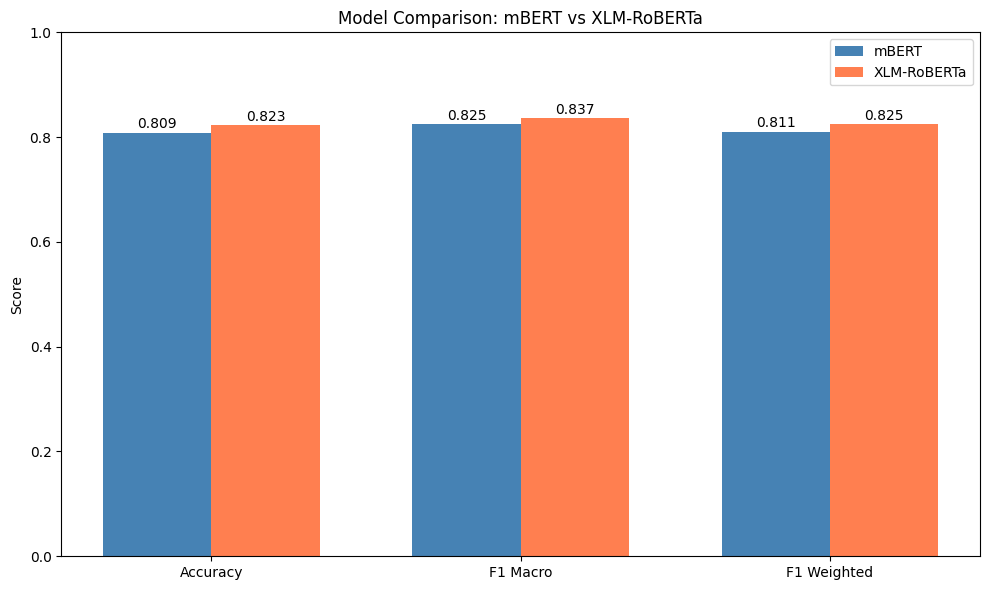


SUMMARY
mBERT - Accuracy: 0.8087, F1 Macro: 0.8251
XLM-R - Accuracy: 0.8233, F1 Macro: 0.8368


In [14]:
import matplotlib.pyplot as plt

# Compare results
metrics = ['eval_accuracy', 'eval_f1_macro', 'eval_f1_weighted']
labels = ['Accuracy', 'F1 Macro', 'F1 Weighted']

mbert_vals = [mbert_results.get(m, 0) for m in metrics]
xlmr_vals = [xlmr_results.get(m, 0) for m in metrics]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mbert_vals, width, label='mBERT', color='steelblue')
bars2 = ax.bar(x + width/2, xlmr_vals, width, label='XLM-RoBERTa', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: mBERT vs XLM-RoBERTa')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Summary
print("\nSUMMARY")
print("=" * 40)
print(f"mBERT - Accuracy: {mbert_results.get('eval_accuracy', 0):.4f}, F1 Macro: {mbert_results.get('eval_f1_macro', 0):.4f}")
print(f"XLM-R - Accuracy: {xlmr_results.get('eval_accuracy', 0):.4f}, F1 Macro: {xlmr_results.get('eval_f1_macro', 0):.4f}")

In [22]:
def predict_emotion(text, model_path):
    """Prediksi emosi untuk teks baru."""
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()

    cleaned = clean_text(text)
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True)

    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred].item()

    return LABEL_NAMES[pred], confidence

# Test
test_texts = [
    "you make me mad",
]

print("Testing mBERT predictions:")
for text in test_texts:
    emotion, conf = predict_emotion(text, OUTPUT_DIR_MBERT)
    print(f"  '{text}' -> {emotion} ({conf:.2%})")

print("\n")
print("Testing XLM-R predictions:")
for text in test_texts:
    emotion, conf = predict_emotion(text, OUTPUT_DIR_XLMR)
    print(f"  '{text}' -> {emotion} ({conf:.2%})")

Testing mBERT predictions:


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  'you make me mad' -> netral (63.65%)


Testing XLM-R predictions:


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  'you make me mad' -> sedih (44.30%)


In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/emotion_classification_models"
os.makedirs(drive_path, exist_ok=True)

if os.path.exists(OUTPUT_DIR_MBERT):
    shutil.copytree(OUTPUT_DIR_MBERT, os.path.join(drive_path, "mbert"), dirs_exist_ok=True)
    print(f"mBERT saved to {drive_path}/mbert")

if os.path.exists(OUTPUT_DIR_XLMR):
    shutil.copytree(OUTPUT_DIR_XLMR, os.path.join(drive_path, "xlmr"), dirs_exist_ok=True)
    print(f"XLM-R saved to {drive_path}/xlmr")

print("Models saved to Google Drive!")

mBERT saved to /content/drive/MyDrive/emotion_classification_models/mbert
XLM-R saved to /content/drive/MyDrive/emotion_classification_models/xlmr
Models saved to Google Drive!
